In [1]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np

# Get to coding

## Initial setup
We start by defining our dimensions and batch sizes for inceptionV3, in order for it to work properly according to its documentation.

In [2]:
# Defining image dimensions and batch size
IMG_SIZE = (299, 299) # InceptionV3 expects inputs of at least 75x75, but 299x299 is standard for its pre-trained weights.
BATCH_SIZE = 128
VAL_SPLIT = 0.33
EPOCHS = 100

DATA_DIR_TRAIN = './grocery_dataset/train'
print("Training data is located at ", DATA_DIR_TRAIN)

DATA_DIR_VAL = './grocery_dataset/val'
print("Validation data is located at ", DATA_DIR_VAL)

DATA_DIR_TEST = './grocery_dataset/test'
print("Validation data is located at ", DATA_DIR_TEST)

Training data is located at  ./grocery_dataset/train
Validation data is located at  ./grocery_dataset/val
Validation data is located at  ./grocery_dataset/test


## Splitting the data

### Datasplit for training

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_TRAIN,
    labels='inferred',
    label_mode='int',
    validation_split=VAL_SPLIT,
    subset='training',
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 15001 files belonging to 15 classes.
Using 10051 files for training.


I0000 00:00:1774349721.195552  474290 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 47187 MB memory:  -> device: 0, name: Quadro RTX 8000, pci bus id: 0000:83:00.0, compute capability: 7.5
I0000 00:00:1774349721.197981  474290 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11542 MB memory:  -> device: 1, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:02:00.0, compute capability: 6.1
I0000 00:00:1774349721.198505  474290 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 11542 MB memory:  -> device: 2, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:03:00.0, compute capability: 6.1


### Datasplit for validation

In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_VAL,
    labels='inferred',
    label_mode='int',
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 15 classes.
Using 990 files for validation.


### Class naming

In [5]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Total number of classes: {num_classes}")
print(f"Product categories: {class_names}")

Total number of classes: 15
Product categories: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


## Optimizing for performance
Adding caching is a good idea, since we dont want the GPU or CPU to wait for data loading.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Generating true labels

In [7]:
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

2026-03-24 11:55:25.931866: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Setting up the model
### Loading the pretrained base of InceptionV3
Using InceptionV3'd ImageNet pre-trained dataset, but excluding the classification layer.

In [8]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# Instantiate the base model
base_model = InceptionV3(
    input_shape=IMG_SIZE + (3,), # Expected input shape
    include_top=False,           # Excluding the 1000-class classifier layer
    weights='imagenet'           # Use weights pre-trained on ImageNet
)

### Freezing the base model
We freeze the weights of the base of InceptionV3, preventing the random training on our dataset from destroying the base knowledge and patterns learned from ImageNet.

In [9]:
base_model.trainable = False # FREEZE the layers

### Adding our own little network
We add our own little network (a new head) on top of the frozen base. This head is responsible for taking the features extracted by InceptionV3  and classifying them into our product categories (num_classes).

In [21]:
global_average_layer = layers.GlobalAveragePooling2D() # Reducing the 3D feature map to a 1D vector
prediction_layer = layers.Dense(num_classes, activation='softmax') # Our final classification layer

data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),   # Flips images randomly
  layers.RandomRotation(0.2),                     # Rotates up to 20% (72 degrees)
  layers.RandomZoom(0.2),                         # Zooms in/out by 20%
])

# Combine the base and the head using the Functional API
model = models.Sequential([
    # Add the augmentation
    data_augmentation,

    # Add a preprocessing layer for InceptionV3's required input scaling (if not handled by the data loader)
    layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(299, 299, 3)),
    base_model,
    global_average_layer,
    layers.Dropout(0.2), # Good practice to prevent overfitting
    prediction_layer
])

model.build(input_shape=(None, 299, 299, 3))

# Print the summary to see your new, smaller model head
model.summary()

model.save("incep_model.keras")
model.save('saved_model_dir', save_format='tf')

/home/bram/.local/lib/python3.11/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,833,519 (83.29 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

ValueError: The `save_format` argument is deprecated in Keras 3. Please remove this argument and pass a file path with either `.keras` or `.h5` extension.Received: save_format=tf

Compiling with adam optimizer to up the performance a little. Adam combines the best features of two optimizers i.e Momentum and RMSprop.


In [11]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

## Time to train!
Training without fine tuning first...

In [12]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
)

Epoch 1/100


2026-03-24 11:56:07.646342: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:15: Filling up shuffle buffer (this may take a while): 50 of 1000
2026-03-24 11:56:08.357031: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.
I0000 00:00:1774349773.936772  474525 cuda_dnn.cc:529] Loaded cuDNN version 91002


79/79 ━━━━━━━━━━━━━━━━━━━━ 95s 657ms/step - accuracy: 0.3363 - loss: 2.2705 - val_accuracy: 0.7636 - val_loss: 1.7064
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 338ms/step - accuracy: 0.7498 - loss: 1.4538 - val_accuracy: 0.9141 - val_loss: 1.0652
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 228ms/step - accuracy: 0.8580 - loss: 0.9819 - val_accuracy: 0.9374 - val_loss: 0.7286
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.8965 - loss: 0.7306 - val_accuracy: 0.9515 - val_loss: 0.5438
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step - accuracy: 0.9124 - loss: 0.5831 - val_accuracy: 0.9586 - val_loss: 0.4346
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.9257 - loss: 0.4820 - val_accuracy: 0.9616 - val_loss: 0.3604
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 232ms/step - accuracy: 0.9360 - loss: 0.4187 - val_accuracy: 0.9646 - val_loss: 0.3104
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - accuracy: 0.9382 - loss: 0.3688 - val_accuracy

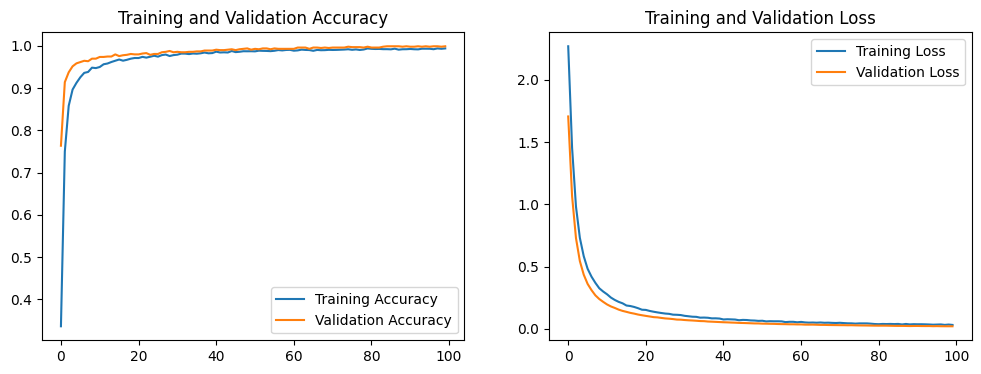

Training accuracy:  [0.33628493547439575, 0.7497761249542236, 0.8580240607261658, 0.8965277075767517, 0.9124464988708496, 0.9256790280342102, 0.9360262751579285, 0.9382150769233704, 0.9483633637428284, 0.9473684430122375, 0.9499552249908447, 0.9564222693443298, 0.9582130908966064, 0.9617948532104492, 0.9647796154022217, 0.967664897441864, 0.9648790955543518, 0.9669684767723083, 0.9696547389030457, 0.9712466597557068, 0.9711471199989319, 0.9739329218864441, 0.9721421003341675, 0.9742314219474792, 0.9766192436218262, 0.9744303822517395, 0.9781116247177124, 0.9794050455093384, 0.9759228229522705, 0.9781116247177124, 0.9791065454483032, 0.9816933870315552, 0.9815938472747803, 0.9804994463920593, 0.9818923473358154, 0.98139488697052, 0.9823898077011108, 0.9841806888580322, 0.9823898077011108, 0.9828872680664062, 0.986270010471344, 0.9842801690101624, 0.9846781492233276, 0.9842801690101624, 0.9877623915672302, 0.985175609588623, 0.9859715700149536, 0.9872649312019348, 0.9871654510498047, 0.9

In [13]:
# Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot the training and validation loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

print("Training accuracy: ", acc)
print("Validation accuracy: ", val_acc)

In [14]:
## Stress testing the model
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def TestAccuracy(path):
    img_path = path
    # Loading the image and resizing it to 299x299 (InceptionV3 standard)
    img = image.load_img(img_path, target_size=(299, 299))
    # Converting image to a numpy array and adding a "batch" dimension
    # (Keras expects a batch of images, even if it's just one)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    # Running the prediction
    predictions = model.predict(img_array)
    # Getting the class with the highest probability
    # score = tf.nn.softmax(predictions[0])
    score = predictions[0]
    predicted_class = class_names[np.argmax(score)]
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    #for p in predictions:
    #    print(p / 100)
    
    print(f"I am {confidence:.2f}% sure this is a(n) {predicted_class} ({predicted_class_index}).")

TestAccuracy('./grocery_dataset/test/Tomato/1080.jpg')
TestAccuracy('./grocery_dataset/test/Cabbage/1080.jpg')
TestAccuracy('./grocery_dataset/test/Cucumber/1080.jpg')
TestAccuracy('./grocery_dataset/test/Carrot/1080.jpg')
TestAccuracy('./grocery_dataset/test/Radish/1080.jpg')
TestAccuracy('./grocery_dataset/test/Papaya/1200.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
I am 100.00% sure this is a(n) Tomato (14).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
I am 99.97% sure this is a(n) Cabbage (5).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
I am 99.92% sure this is a(n) Cucumber (9).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
I am 99.98% sure this is a(n) Carrot (7).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
I am 99.95% sure this is a(n) Radish (13).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
I am 98.99% sure this is a(n) Papaya (10).


### Setting up confusion matrix and heatmap

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_grocery_confusion_matrix(y_true, y_pred, class_names):
    # 1. Compute the matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Set up the figure size
    plt.figure(figsize=(10, 8))
    
    # 3. Create the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.title('Grocery Recognition: Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Converting the model to TFJS

In [20]:
import tensorflow as tf
import tensorflowjs as tfjs

# 1. Load your newly trained Keras 3 model
model = tf.keras.models.load_model('./incep_model.keras')

# 2. Save it directly to the TensorFlow.js format
tfjs.converters.save_keras_model(model, './tfjs_model')

print("Conversion complete!")

NotFoundError: /home/bram/.local/lib/python3.11/site-packages/tensorflow_decision_forests/tensorflow/ops/inference/inference.so: undefined symbol: _ZN10tensorflow20OpKernelConstruction21CtxFailureWithWarningEPKciRKN4absl12lts_202308026StatusE